In [23]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
import pysindy as ps
import matplotlib.pyplot as plt

In [24]:
import os
from pathlib import Path
# Move to the NeuralOperatorSINDy repo root regardless of where Jupyter started the
# kernel (this notebook lives at experiments/lorenz63/analysis.ipynb).
if Path.cwd().name == "lorenz63":
    os.chdir(Path.cwd().parents[1])
print(Path.cwd())

c:\Users\mra15\OneDrive\MSc2026\Code\NO_SINDy_NO\4 - NO-SINDy\NeuralOperatorSINDy


In [25]:
from scipy.integrate import odeint

from src.training import (
    load_or_create_lorenz_data, sample_batch, sample_batch_subsampled, SINDyAE, train, theta_jax,
    PoolingEncoder, DeepSetPooling, make_decoder, save_checkpoint, load_checkpoint,
)
from experiments.lorenz63.config import Config

In [26]:
cfg = Config()

# Data creation for lifted Lorenz63 System from Champion et al. (2019) "Data-driven
# discovery of coordinates and governing equations" -- cached under
# experiments/lorenz63 so repeated runs reuse the same data instead of regenerating.
lorenz63_dir = Path.cwd() / "experiments" / "lorenz63"
training_data = load_or_create_lorenz_data(
    lorenz63_dir / "training_data.npz", cfg.model.N_ICS, cfg.model.NOISE_STRENGTH,
    linear=cfg.model.LINEAR_OBS,
)
validation_data = load_or_create_lorenz_data(
    lorenz63_dir / "validation_data.npz", cfg.model.N_VAL, cfg.model.NOISE_STRENGTH,
    linear=cfg.model.LINEAR_OBS,
)

In [27]:
# Create a polynomial library for the SINDy model
_ps_lib = ps.PolynomialLibrary(degree=cfg.model.POLY_ORDER, include_bias=True)
_ps_lib.fit([np.zeros((2, cfg.model.LATENT_DIM))])
N_FEATURES = _ps_lib.n_output_features_
FEAT_NAMES = list(_ps_lib.get_feature_names_out([f'z{i}' for i in range(cfg.model.LATENT_DIM)]))
print(f'Library: {N_FEATURES} features  {FEAT_NAMES}')

model = SINDyAE(
    encoder=PoolingEncoder(
        latent_dim=cfg.model.LATENT_DIM,
        is_variational=False,
        pooling_fn=DeepSetPooling(mlp_dim=64, mlp_n_hidden_layers=2),
    ),
    decoder=make_decoder(cfg),
    n_features=N_FEATURES,
    latent_dim=cfg.model.LATENT_DIM,
    poly_order=cfg.model.POLY_ORDER,
)

Library: 20 features  ['1', 'z0', 'z1', 'z2', 'z0^2', 'z0 z1', 'z0 z2', 'z1^2', 'z1 z2', 'z2^2', 'z0^3', 'z0^2 z1', 'z0^2 z2', 'z0 z1^2', 'z0 z1 z2', 'z0 z2^2', 'z1^3', 'z1^2 z2', 'z1 z2^2', 'z2^3']


In [28]:
# key = jax.random.PRNGKey(cfg.model.SEED)
# key, init_key, subsample_key = jax.random.split(key, 3)
# rng = np.random.default_rng(cfg.model.SEED)

# # cfg.model.SUBSAMPLE_POINTS toggles the mesh-invariance test: each batch row gets its
# # own independently-random cfg.model.N_SUB-point subset of the grid instead of every
# # row sharing the same fixed full grid.
# if cfg.model.SUBSAMPLE_POINTS:
#     u0, udot0, x0 = sample_batch_subsampled(training_data, cfg.training.BATCH_SIZE, cfg.model.N_SUB, rng, subsample_key)
# else:
#     u0, udot0, x0 = sample_batch(training_data, cfg.training.BATCH_SIZE, rng)

# mask = jnp.ones((N_FEATURES, cfg.model.LATENT_DIM))
# params = model.init(init_key, u0, udot0, x0, mask)['params']

# # Resume-aware: if a prior run (this cell, or src/training.py's __main__) already
# # checkpointed this config, this picks up from state.step -- a fast no-op if training
# # already finished. Safe to re-run this cell any time, including after an SSH drop
# # (run inside tmux/screen on the remote server so the underlying process survives a
# # dropped connection regardless -- see checkpoint_every below as the safety net if it
# # doesn't).
# checkpoint_path = lorenz63_dir / "checkpoint_NO_SINDy_08_07__11_04___no_dz.pkl"
# resume_from = load_checkpoint(checkpoint_path)
# if resume_from is not None:
#     print(f'found existing checkpoint at {checkpoint_path}, resuming')

# state, mask, loss_hist = train(
#     cfg, model, params, mask, training_data, rng,
#     checkpoint_path=checkpoint_path,
#     checkpoint_every=50_000,
#     resume_from=resume_from,
#     key=key,
# )

### Load a trained checkpoint instead of training

Run this cell **instead of** the training cell above (skip that one) if
`experiments/lorenz63/checkpoint.pkl` already holds a finished (or in-progress) run --
e.g. copied over from the university GPU machine -- and you just want to analyze it
without resuming or continuing training. It reconstructs `state`/`mask`/`loss_hist` in
the same shape the training cell produces, so every cell below works unchanged either
way. `loss_hist` is whatever the checkpoint happened to have saved -- if it's empty or
was stripped out (e.g. to keep the transferred file small), the loss-curve cell below
detects that and just skips the plot rather than erroring.

In [29]:
import types

checkpoint_path = lorenz63_dir / "checkpoint.pkl"
ckpt = load_checkpoint(checkpoint_path)
if ckpt is None:
    raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")

state = types.SimpleNamespace(params=jax.tree_util.tree_map(jnp.asarray, ckpt['params']))
mask = jnp.asarray(ckpt['mask'])
loss_hist = ckpt.get('loss_hist', [])  # may be empty/excluded -- downstream cells handle that

total_steps = cfg.training.MAX_STEPS + cfg.training.REFINEMENT_STEPS
print(f"loaded checkpoint @ step {ckpt['step']}/{total_steps}")
print(f"active terms: {int(np.array(mask).sum())} / {mask.size}")
print(f"loss_hist entries available: {len(loss_hist)}")

loaded checkpoint @ step 382000/1500500
active terms: 12 / 60
loss_hist entries available: 382000


## Results

C:\Users\mra15\AppData\Local\Temp\ipykernel_18816\3551290418.py:11: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


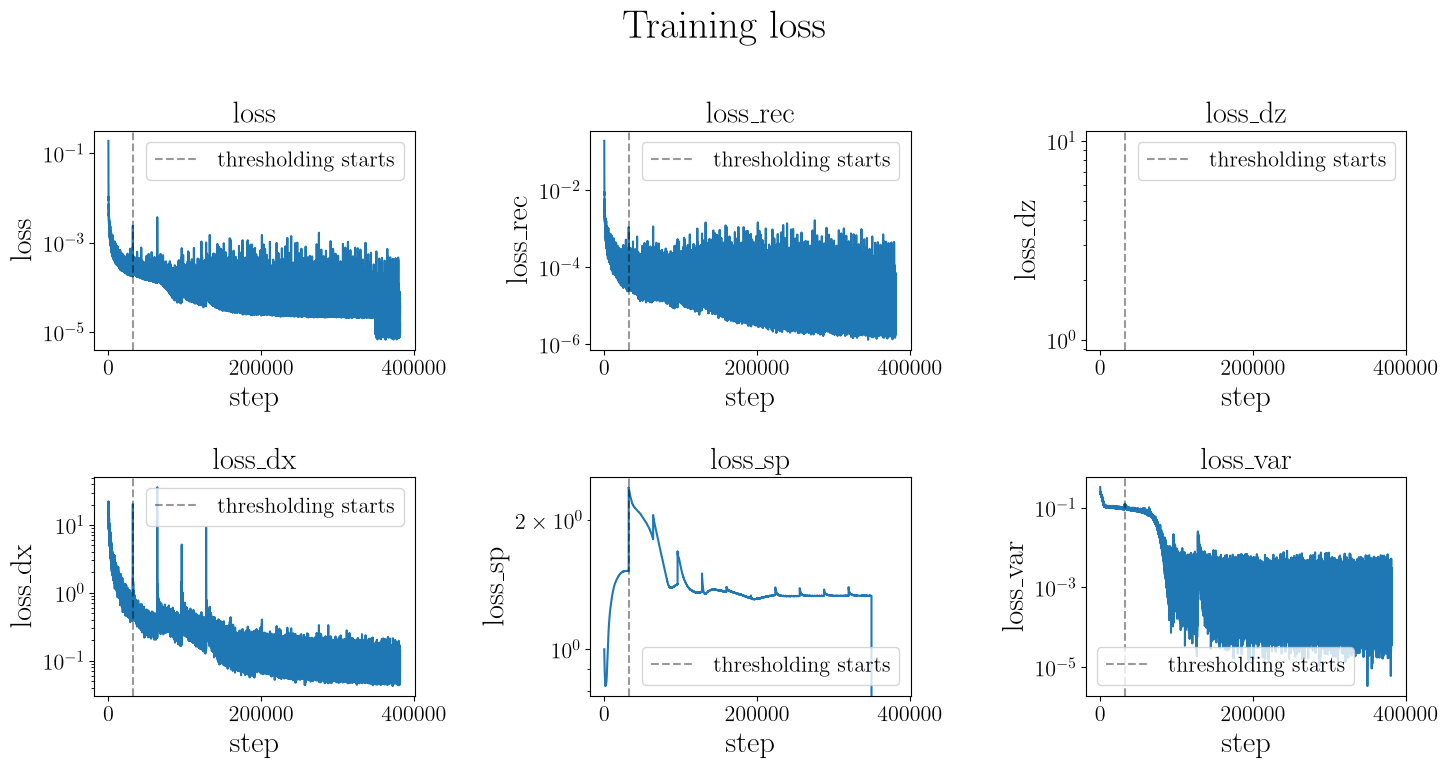

In [30]:
if not loss_hist:
    print("no loss history available (checkpoint-only analysis) -- skipping loss curve plot")
else:
    loss_arr = {k: np.array([h[k] for h in loss_hist]) for k in loss_hist[0]}

    loss_names = ["loss", "loss_rec", "loss_dz", "loss_dx", "loss_sp", "loss_var"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, name in zip(axes.flat, loss_names):
        ax.plot(loss_arr[name])
        ax.axvline(cfg.loss.THRESH_START, color="k", linestyle="--", alpha=0.4, label="thresholding starts")
        ax.set_yscale("log")
        ax.set_xlabel("step")
        ax.set_ylabel(name)
        ax.set_title(name)
        ax.legend()
    plt.suptitle("Training loss")
    plt.tight_layout()
    plt.show()

### Input field vs. reconstruction

Sanity check on the autoencoder itself, independent of the SINDy dynamics: does
`decoder(encoder(u))` actually look like `u`? `loss_rec` in the loss curves above gives
the aggregate number; this shows it directly as a function of the spatial coordinate
`y`, for a handful of individual snapshots.

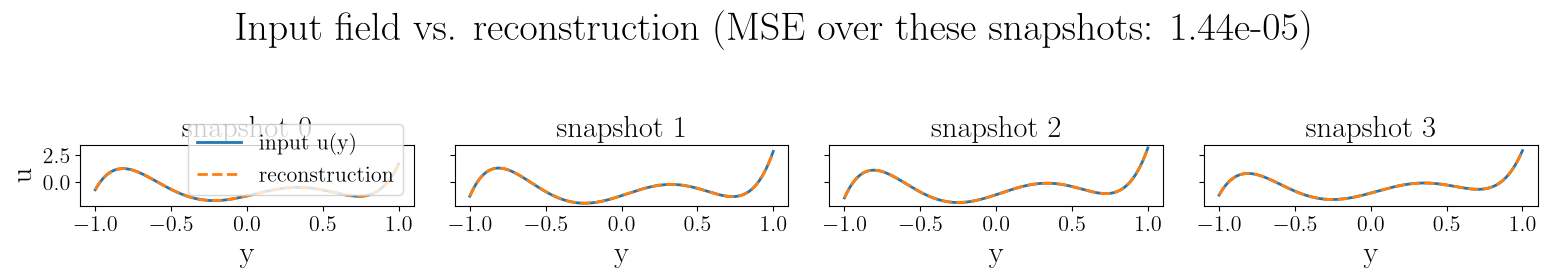

In [31]:
n_examples = 4
idx_examples = np.arange(n_examples)

u_ex = jnp.asarray(validation_data['x'][idx_examples])[..., None]
udot_ex = jnp.asarray(validation_data['dx'][idx_examples])[..., None]
x_ex = jnp.broadcast_to(
    jnp.asarray(validation_data['y_spatial'])[None, :, None],
    (n_examples, validation_data['y_spatial'].shape[0], 1),
)

u_hat_ex, *_ = model.apply({'params': state.params}, u_ex, udot_ex, x_ex, mask)
u_hat_ex = np.array(u_hat_ex)

fig, axes = plt.subplots(1, n_examples, figsize=(4 * n_examples, 3), sharey=True)
y_plot = np.array(validation_data['y_spatial'])
for i, ax in enumerate(axes):
    ax.plot(y_plot, np.array(u_ex[i, :, 0]), linewidth=2, label='input u(y)')
    ax.plot(y_plot, u_hat_ex[i, :, 0], '--', linewidth=2, label='reconstruction')
    ax.set_title(f'snapshot {idx_examples[i]}')
    ax.set_xlabel('y')
    if i == 0:
        ax.set_ylabel('u')
        ax.legend()

rec_err = np.mean((u_hat_ex - np.array(u_ex)) ** 2)
plt.suptitle(f'Input field vs. reconstruction (MSE over these snapshots: {rec_err:.2e})')
plt.tight_layout()
plt.show()

### Input field vs. reconstruction, over time

The snapshot comparison above only shows a handful of fixed-`t` slices. This adds the
temporal component as a third axis -- `(y, t, u)` surfaces over one full validation
trajectory -- so reconstruction quality is visible across the entire spatiotemporal
domain at once, not just at the four timesteps picked above.

visualizing validation trajectory 5


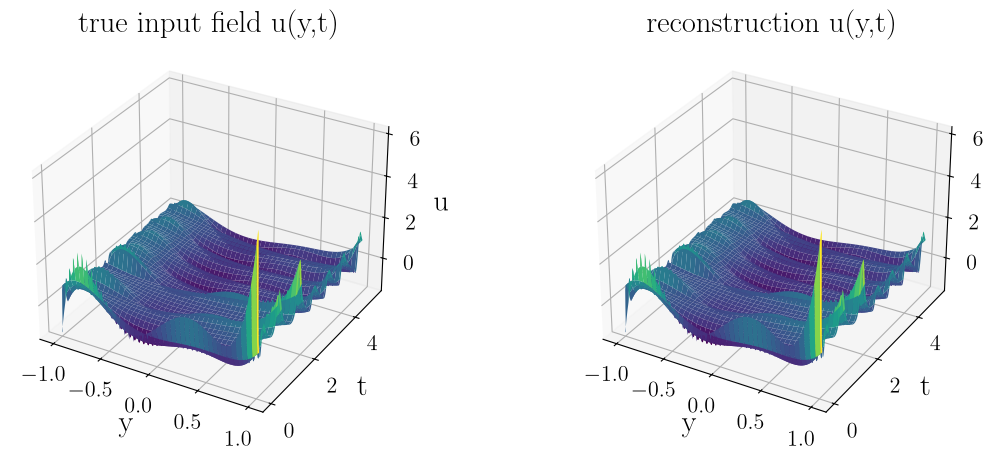

reconstruction MSE over full trajectory: 2.087e-06


In [32]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

I_SURF = np.random.randint(cfg.model.N_VAL)  # a different validation trajectory each time this cell runs
n_val = cfg.model.N_VAL
n_steps = validation_data['t'].shape[0]
t_grid = validation_data['t']
print(f'visualizing validation trajectory {I_SURF}')

u_traj = jnp.asarray(validation_data['x'].reshape(n_val, n_steps, -1)[I_SURF])[..., None]
udot_traj = jnp.asarray(validation_data['dx'].reshape(n_val, n_steps, -1)[I_SURF])[..., None]
x_traj = jnp.broadcast_to(
    jnp.asarray(validation_data['y_spatial'])[None, :, None],
    (n_steps, validation_data['y_spatial'].shape[0], 1),
)

u_hat_traj, *_ = model.apply({'params': state.params}, u_traj, udot_traj, x_traj, mask)
u_hat_traj = np.array(u_hat_traj)[:, :, 0]
u_true_traj = np.array(u_traj)[:, :, 0]

Y, T = np.meshgrid(np.array(validation_data['y_spatial']), t_grid)

if cfg.model.SUBSAMPLE_POINTS:
    # Show what the model actually sees during training when subsampling is on: every
    # sample gets its own independent random N_SUB-point subset (matching
    # sample_batch_subsampled -- every individual sample has its own point cloud, not
    # just every step), encoded from just those sparse points, then decoded back out
    # at the FULL grid -- sparse in, dense out -- to see whether the model can
    # reconstruct the whole field having only ever observed a fraction of it.
    sub_key = jax.random.PRNGKey(np.random.randint(1_000_000))
    keys = jax.random.split(sub_key, n_steps)
    y_full = jnp.asarray(validation_data['y_spatial'])
    n_points_full = y_full.shape[0]

    def pick(k, u_row):
        sub_idx = jax.random.choice(k, n_points_full, shape=(cfg.model.N_SUB,), replace=False)
        return u_row[sub_idx], y_full[sub_idx]

    u_sub, x_sub = jax.vmap(pick)(keys, jnp.asarray(u_true_traj))   # [n_steps, N_SUB] each
    z_sub = model.encoder.apply({'params': state.params['encoder']}, u_sub[..., None], x_sub[..., None])
    u_hat_from_sub = model.decoder.apply({'params': state.params['decoder']}, z_sub, x_traj)
    u_hat_from_sub = np.array(u_hat_from_sub)[:, :, 0]   # [n_steps, n_points_full] -- dense reconstruction from sparse input

    T_sub = np.broadcast_to(t_grid[:, None], np.array(x_sub).shape)

    fig = plt.figure(figsize=(18, 5), frameon=False)

    # 1. True input field, full resolution
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot_surface(Y, T, u_true_traj, cmap='viridis', edgecolor='none')
    ax1.set_xlabel('y'); ax1.set_ylabel('t'); ax1.set_zlabel('u')
    ax1.set_title('true input field u(y,t)')
    ax1.axis('off')
    

    # 2. ONLY the sampled points -- not overlaid on the full field -- so this shows
    # exactly what the model observes: a sparse, per-step point cloud, nothing more.
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.scatter(np.array(x_sub).ravel(), T_sub.ravel(), np.array(u_sub).ravel(),
                c=np.array(u_sub).ravel(), cmap='viridis', s=4)
    ax2.set_xlabel('y'); ax2.set_ylabel('t'); ax2.set_zlabel('u')
    ax2.set_title(f'subsampled input only ({cfg.model.N_SUB}/{n_points_full} pts/step)')

    # 3. Reconstruction, full resolution, decoded from the sparse input above
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.plot_surface(Y, T, u_hat_from_sub, cmap='viridis', edgecolor='none')
    ax3.set_xlabel('y'); ax3.set_ylabel('t'); ax3.set_zlabel('u')
    ax3.set_title('reconstruction at full resolution')

    plt.tight_layout()
    plt.show()

    mse_sub = np.mean((u_hat_from_sub - u_true_traj) ** 2)
    print(f'reconstruction MSE (full-res output from sparse input) over full trajectory: {mse_sub:.3e}')
else:
    fig = plt.figure(figsize=(12, 5))

    # 1. True input field
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(Y, T, u_true_traj, cmap='viridis', edgecolor='none')
    ax1.set_xlabel('y'); ax1.set_ylabel('t'); ax1.set_zlabel('u')
    ax1.set_title('true input field u(y,t)')

    # 2. Reconstruction
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(Y, T, u_hat_traj, cmap='viridis', edgecolor='none')
    ax2.set_xlabel('y'); ax2.set_ylabel('t'); ax2.set_zlabel('u')
    ax2.set_title('reconstruction u(y,t)')

    plt.tight_layout()
    plt.show()

    print(f'reconstruction MSE over full trajectory: {np.mean((u_hat_traj - u_true_traj) ** 2):.3e}')


### Latent space

Encode the validation trajectories and look at the learned latent code: its time series
and how well it correlates with the true (normalised) Lorenz state.

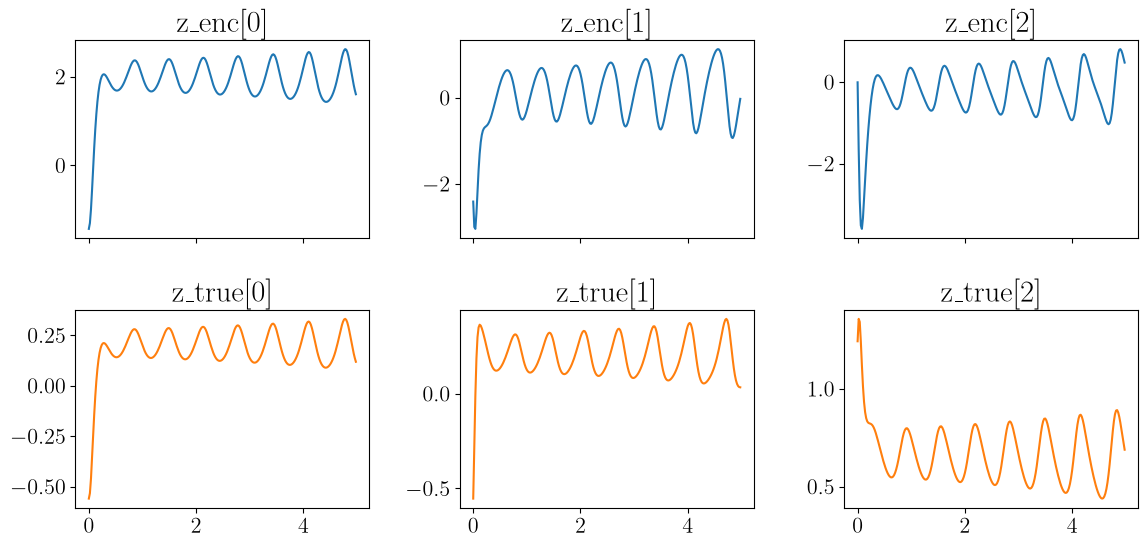

In [33]:
def encode_batch(u, x):
    return np.array(model.encoder.apply({'params': state.params['encoder']}, u, x))

n_steps = validation_data['t'].shape[0]
n_val = cfg.model.N_VAL
t_grid = validation_data['t']
y_spatial = jnp.asarray(validation_data['y_spatial'])[None, :, None]

u_val_traj = validation_data['x'].reshape(n_val, n_steps, -1)[..., None]
z_true_traj = validation_data['z'].reshape(n_val, n_steps, cfg.model.LATENT_DIM)

z_enc_traj = np.zeros((n_val, n_steps, cfg.model.LATENT_DIM))
for i in range(n_val):
    x_b = jnp.broadcast_to(y_spatial, (n_steps, y_spatial.shape[1], 1))
    z_enc_traj[i] = encode_batch(jnp.asarray(u_val_traj[i]), x_b)

fig, axes = plt.subplots(2, cfg.model.LATENT_DIM, figsize=(4 * cfg.model.LATENT_DIM, 6), sharex=True)
for d in range(cfg.model.LATENT_DIM):
    axes[0, d].plot(t_grid, z_enc_traj[0, :, d])
    axes[0, d].set_title(f'z_enc[{d}]')
    axes[1, d].plot(t_grid, z_true_traj[0, :, d], color='tab:orange')
    axes[1, d].set_title(f'z_true[{d}]')
plt.tight_layout()
plt.show()

corr = np.array([
    [np.corrcoef(z_enc_traj[:, :, i].ravel(), z_true_traj[:, :, j].ravel())[0, 1]
     for j in range(cfg.model.LATENT_DIM)]
    for i in range(cfg.model.LATENT_DIM)
])

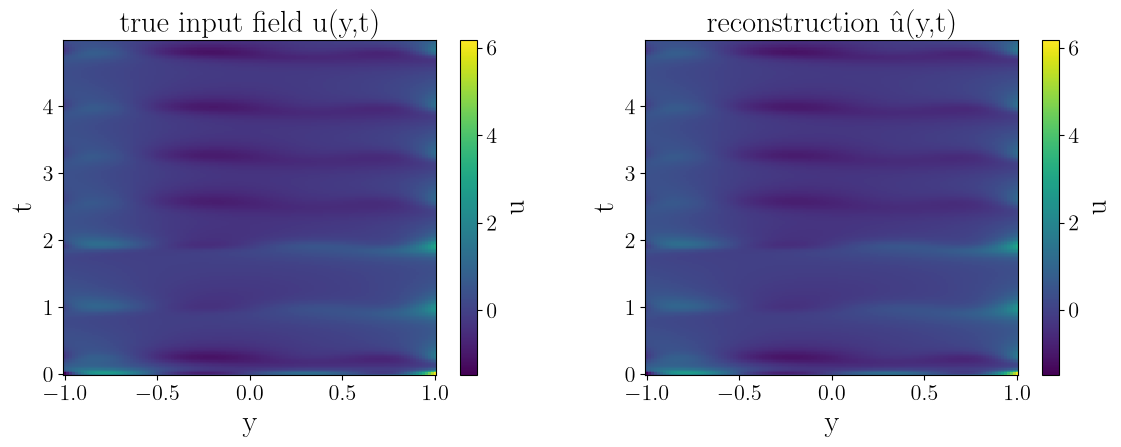

reconstruction MSE over full trajectory: 2.087e-06


In [34]:
if cfg.model.SUBSAMPLE_POINTS:
    # Show what the model actually sees during training when subsampling is on: every
    # timestep gets its own independent random N_SUB-point subset (matching
    # sample_batch_subsampled -- every individual sample has its own point cloud, not
    # just every step), encoded from just those sparse points, then decoded back out
    # at the FULL grid -- sparse in, dense out -- to see whether the model can
    # reconstruct the whole field having only ever observed a fraction of it.
    sub_key = jax.random.PRNGKey(np.random.randint(1_000_000))
    keys = jax.random.split(sub_key, n_steps)
    y_full = jnp.asarray(validation_data['y_spatial'])
    n_points_full = y_full.shape[0]

    def pick(k, u_row):
        sub_idx = jax.random.choice(k, n_points_full, shape=(cfg.model.N_SUB,), replace=False)
        return u_row[sub_idx], y_full[sub_idx]

    u_sub, x_sub = jax.vmap(pick)(keys, jnp.asarray(u_true_traj))   # [n_steps, N_SUB] each
    z_sub = model.encoder.apply({'params': state.params['encoder']}, u_sub[..., None], x_sub[..., None])
    u_hat_from_sub = model.decoder.apply({'params': state.params['decoder']}, z_sub, x_traj)
    u_hat_from_sub = np.array(u_hat_from_sub)[:, :, 0]   # [n_steps, n_points_full] -- dense reconstruction from sparse input

    fig = plt.figure(figsize=(16, 5))
    
    # 1. True input field (Top-down)
    ax1 = fig.add_subplot(1, 3, 1)
    im1 = ax1.pcolormesh(Y, T, u_true_traj, cmap='viridis', shading='auto')
    fig.colorbar(im1, ax=ax1, label='u')
    ax1.set_xlabel('y'); ax1.set_ylabel('t')
    ax1.set_title('true input field u(y,t)')

    # 2. Subsampled input overlaid on full data
    ax2 = fig.add_subplot(1, 3, 2)
    T_sub = np.broadcast_to(t_grid[:, None], np.array(x_sub).shape)
    # Plot theoretically full data in the background (slightly faded for contrast)
    im2 = ax2.pcolormesh(Y, T, u_true_traj, cmap='viridis', shading='auto', alpha=0.6)
    # Overlay the subsampled points in red
    ax2.scatter(np.array(x_sub).ravel(), T_sub.ravel(), c='red', s=2)
    fig.colorbar(im2, ax=ax2, label='u')
    ax2.set_xlabel('y'); ax2.set_ylabel('t')
    ax2.set_title(f'subsampled input ({cfg.model.N_SUB}/{n_points_full} pts/step in red)')

    # 3. Reconstruction (Top-down)
    ax3 = fig.add_subplot(1, 3, 3)
    im3 = ax3.pcolormesh(Y, T, u_hat_from_sub, cmap='viridis', shading='auto')
    fig.colorbar(im3, ax=ax3, label='u')
    ax3.set_xlabel('y'); ax3.set_ylabel('t')
    ax3.set_title('reconstruction at full resolution')

    plt.tight_layout()
    plt.show()

    mse_sub = np.mean((u_hat_from_sub - u_true_traj) ** 2)
    print(f'reconstruction MSE (full-res output from sparse input) over full trajectory: {mse_sub:.3e}')
else:
    fig = plt.figure(figsize=(12, 5))
    
    # 1. True input field (Top-down)
    ax1 = fig.add_subplot(1, 2, 1)
    im1 = ax1.pcolormesh(Y, T, u_true_traj, cmap='viridis', shading='auto')
    fig.colorbar(im1, ax=ax1, label='u')
    ax1.set_xlabel('y')
    ax1.set_ylabel('t')
    ax1.set_title('true input field u(y,t)')

    # 2. Reconstruction (Top-down)
    ax2 = fig.add_subplot(1, 2, 2)
    im2 = ax2.pcolormesh(Y, T, u_hat_traj, cmap='viridis', shading='auto')
    fig.colorbar(im2, ax=ax2, label='u')
    ax2.set_xlabel('y')
    ax2.set_ylabel('t')
    ax2.set_title('reconstruction û(y,t)')

    plt.tight_layout()
    plt.show()

    print(f'reconstruction MSE over full trajectory: {np.mean((u_hat_traj - u_true_traj) ** 2):.3e}')

In [35]:
np.set_printoptions(precision=3, suppress=True)
print("corr matrix (rows=z_enc_i, cols=z_true_j):")
print(corr)
print()
print("per z_enc row -> best matching z_true (argmax |corr|):", np.argmax(np.abs(corr), axis=1))
print("max |corr| per z_enc row:", np.abs(corr).max(axis=1))

corr matrix (rows=z_enc_i, cols=z_true_j):
[[ 0.999  0.802  0.056]
 [ 0.025  0.022 -0.998]
 [ 0.004 -0.583  0.009]]

per z_enc row -> best matching z_true (argmax |corr|): [0 2 1]
max |corr| per z_enc row: [0.999 0.998 0.583]


### Linear coordinate recovery

Correlation only checks each `z_true` axis against its single best-matching `z_enc`
axis. This instead fits each `z_true` axis as a full linear *combination* of all
`z_enc` axes (Champion et al.'s coordinate-recovery check, their Fig. 4) -- the right
test when the encoder may have found a rotated/mixed coordinate system rather than an
axis-aligned copy of the true state, then pushes the discovered model through that same
map into the true-state frame so it can be read directly against the true Lorenz
equations. R^2 close to 1 for all three axes means the discovered coordinates are (up
to this affine map) the same system as the true state; low R^2 means they aren't, and
the transformed equations below won't line up no matter what.

In [36]:
def fit_linear_map(z_enc, z_true, xi_masked, poly_order, latent_dim, feat_names,
                    keep_frac=0.02, precision=3):
    xi_masked = np.asarray(xi_masked)

    print("model in the encoder's own (untransformed) frame:")
    lines = []
    for d in range(latent_dim):
        col = xi_masked[:, d]
        cutoff = keep_frac * np.abs(col).max()
        terms = [f"{coef:+.{precision}f} {name}" for coef, name in zip(col, feat_names) if abs(coef) >= cutoff]
        lines.append(f"dz{d}/dt = {' '.join(terms) if terms else '0'}")
    print("\n".join(lines))
    print()

    z_enc = np.asarray(z_enc)
    z_true = np.asarray(z_true)
    N = z_enc.shape[0]

    X = np.concatenate([z_enc, np.ones((N, 1))], axis=1)
    W, _, _, _ = np.linalg.lstsq(X, z_true, rcond=None)
    A, b = W[:-1].T, W[-1]

    z_pred = X @ W
    ss_res = np.sum((z_true - z_pred) ** 2, axis=0)
    ss_tot = np.sum((z_true - z_true.mean(axis=0)) ** 2, axis=0)
    r2 = 1 - ss_res / ss_tot

    A_inv = np.linalg.inv(A)
    z_from_true = (z_true - b) @ A_inv.T

    Theta_true = np.array(theta_jax(jnp.asarray(z_true), poly_order, latent_dim))
    Theta_z = np.array(theta_jax(jnp.asarray(z_from_true), poly_order, latent_dim))
    M, _, _, _ = np.linalg.lstsq(Theta_true, Theta_z, rcond=None)

    Xi_true_frame = M @ (xi_masked @ A.T)

    print("A =\n", A)
    print("b =", b)
    print("R^2 per true-state axis:", r2)
    print()
    for d in range(latent_dim):
        col = Xi_true_frame[:, d]
        order = np.argsort(-np.abs(col))
        print(f"dz{d}/dt terms sorted by |coef| (top 8): "
              + ", ".join(f"{feat_names[i]}={col[i]:.4f}" for i in order[:8]))
    print()
    print("model transformed into the true-state frame (relative threshold):")
    lines = []
    for d in range(latent_dim):
        col = Xi_true_frame[:, d]
        cutoff = keep_frac * np.abs(col).max()
        terms = [f"{coef:+.{precision}f} {name}" for coef, name in zip(col, feat_names) if abs(coef) >= cutoff]
        lines.append(f"dz{d}/dt = {' '.join(terms) if terms else '0'}")
    print("\n".join(lines))

    return A, b, r2, Xi_true_frame


xi_final = np.array(state.params['xi']) * np.array(mask)
A, b, r2, Xi_true_frame = fit_linear_map(
    z_enc_traj.reshape(-1, cfg.model.LATENT_DIM),
    z_true_traj.reshape(-1, cfg.model.LATENT_DIM),
    xi_final, cfg.model.POLY_ORDER, cfg.model.LATENT_DIM, FEAT_NAMES,
)


model in the encoder's own (untransformed) frame:
dz0/dt = -0.645 z0 -6.963 z2
dz1/dt = +15.587 z0 -6.981 z2 -7.489 z0^2 -1.586 z0 z1 +5.824 z0 z2
dz2/dt = -0.670 z0 +12.958 z1 -10.427 z2 -12.780 z0 z1 -0.434 z1^2

A =
 [[ 0.212  0.009 -0.002]
 [ 0.196  0.01  -0.149]
 [ 0.008 -0.218  0.003]]
b = [-0.221 -0.218  0.671]
R^2 per true-state axis: [1.    0.999 0.998]

dz0/dt terms sorted by |coef| (top 8): z1=9.9910, z0=-9.5829, z0 z1=-1.7704, z0 z2=-0.3950, z2=0.0799, z1 z2=-0.0691, z0^2=0.0551, z1^2=0.0262
dz1/dt terms sorted by |coef| (top 8): z0 z2=-41.3988, z0=29.1138, z0 z1=-2.5933, z0^2=2.2646, z1=-1.6199, z1 z2=0.5505, z2^2=-0.4139, z2=0.3867
dz2/dt terms sorted by |coef| (top 8): z0 z1=40.5076, z0 z2=-5.0788, z0=4.7998, z1=-2.0695, z1 z2=1.8057, z2=-1.3016, 1=-0.7957, z1^2=-0.5989

model transformed into the true-state frame (relative threshold):
dz0/dt = -9.583 z0 +9.991 z1 -1.770 z0 z1 -0.395 z0 z2
dz1/dt = +29.114 z0 -1.620 z1 +2.265 z0^2 -2.593 z0 z1 -41.399 z0 z2
dz2/dt = +4.8

### Rescaling Xi_true_frame to raw (textbook-Lorenz-comparable) units

This is a display-only cleanup, not a training change. `Xi_true_frame` (from
`fit_linear_map` above) is already expressed in the true, *normalized* (by
`normalization=1/40`) Lorenz frame -- valid target for this rescaling specifically
because that transform already put us in the true system's own coordinates, unlike
the raw (`z_enc`-frame) `xi`, whose natural scale has no fixed relationship to `1/40`
and should NOT be rescaled this way.

A degree-`d` term's coefficient in the normalized frame equals the raw (unnormalized)
Lorenz coefficient times `normalization**(d-1)` -- linear terms (`d=1`) are unchanged,
quadratic terms (`d=2`) get divided by 40, cubic (`d=3`) by 1600. Inverting that
recovers coefficients directly comparable to the textbook constants
(`sigma=10, rho=28, beta=8/3`, unit nonlinear couplings) instead of needing to
mentally divide by 40 every time.

In [37]:
from itertools import combinations_with_replacement

def library_degrees(poly_order, latent_dim):
    """Degree of each theta_jax/PolynomialLibrary column, in the same order."""
    degrees = [0]  # bias
    for deg in range(1, poly_order + 1):
        for _ in combinations_with_replacement(range(latent_dim), deg):
            degrees.append(deg)
    return np.array(degrees)


def rescale_to_raw_units(Xi_true_frame, poly_order, latent_dim, normalization=1 / 40):
    degrees = library_degrees(poly_order, latent_dim)
    scale = normalization ** (degrees - 1)
    return Xi_true_frame * scale[:, None]


Xi_raw_units = rescale_to_raw_units(Xi_true_frame, cfg.model.POLY_ORDER, cfg.model.LATENT_DIM)
keep_frac = 0.02

# Term SELECTION here matches the same (normalized) frame fit_linear_map itself used --
# rescaling to raw units is display-only and must never change WHICH terms are shown,
# only the magnitude they're shown with. Applying a fixed absolute cutoff to the
# rescaled values instead applies a much LAXER effective bar to quadratic/cubic terms,
# since dividing by 40 (or 1600) shrinks them without shrinking the cutoff to match.
lines = []
for d in range(cfg.model.LATENT_DIM):
    col_normalized = Xi_true_frame[:, d]
    col_raw = Xi_raw_units[:, d]
    cutoff = keep_frac * np.abs(col_normalized).max()
    keep = np.abs(col_normalized) >= cutoff
    terms = [f"{coef:+.4f} {name}" for coef, name, k in zip(col_raw, FEAT_NAMES, keep) if k]
    lines.append(f"dz{d}/dt = {' '.join(terms) if terms else '0'}")

print("model transformed into the true-state frame, rescaled to raw (textbook) units:")
print("\n".join(lines))
print()

# For comparison: threshold applied AFTER rescaling instead (relative to each rescaled
# column's own max). Since rescaling shrinks quadratic/cubic terms unevenly (/40, /1600)
# relative to linear terms, this cutoff is generally a DIFFERENT, laxer bar for
# higher-degree terms than the one above -- this is exactly the mechanism that
# resurfaces small terms the consistent-selection view (above) correctly drops. Shown
# deliberately, so the difference is visible side by side rather than silently
# changing which terms get reported.
lines_after = []
for d in range(cfg.model.LATENT_DIM):
    col_raw = Xi_raw_units[:, d]
    cutoff_after = keep_frac * np.abs(col_raw).max()
    keep_after = np.abs(col_raw) >= cutoff_after
    terms = [f"{coef:+.4f} {name}" for coef, name, k in zip(col_raw, FEAT_NAMES, keep_after) if k]
    lines_after.append(f"dz{d}/dt = {' '.join(terms) if terms else '0'}")

print("same rescaled coefficients, but threshold applied AFTER rescaling instead (for comparison):")
print("\n".join(lines_after))
print()
print("reference -- raw Lorenz: dz0/dt = -10 z0 +10 z1")
print("             dz1/dt = +28 z0 -1 z1 -1 z0 z2")
print("             dz2/dt = -2.667 z2 +1 z0 z1")


model transformed into the true-state frame, rescaled to raw (textbook) units:
dz0/dt = -9.5829 z0 +9.9910 z1 -0.0443 z0 z1 -0.0099 z0 z2
dz1/dt = +29.1138 z0 -1.6199 z1 +0.0566 z0^2 -0.0648 z0 z1 -1.0350 z0 z2
dz2/dt = +4.7998 z0 -2.0695 z1 -1.3016 z2 +1.0127 z0 z1 -0.1270 z0 z2 +0.0451 z1 z2

same rescaled coefficients, but threshold applied AFTER rescaling instead (for comparison):
dz0/dt = +0.4461 1 -9.5829 z0 +9.9910 z1
dz1/dt = -1.4515 1 +29.1138 z0 -1.6199 z1 -1.0350 z0 z2
dz2/dt = -31.8276 1 +4.7998 z0 -2.0695 z1 -1.3016 z2 +1.0127 z0 z1

reference -- raw Lorenz: dz0/dt = -10 z0 +10 z1
             dz1/dt = +28 z0 -1 z1 -1 z0 z2
             dz2/dt = -2.667 z2 +1 z0 z1


### Forecasting

Integrate the learned SINDy ODE (`theta(z) @ xi`, using the trained + thresholded mask)
forward from an encoded latent state, and compare against the encoder's own trajectory
over the forecast horizon (not the raw ground-truth Lorenz state, since the encoder need
not have learned an axis-aligned copy of it).

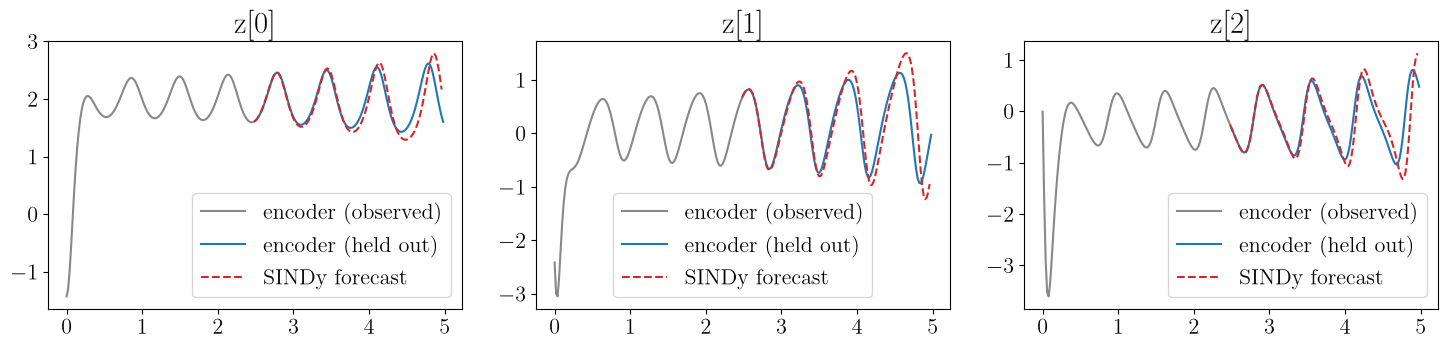

In [38]:
xi_final = np.array(state.params['xi']) * np.array(mask)

def sindy_rhs(z, t):
    theta = np.array(theta_jax(jnp.asarray(z)[None, :], cfg.model.POLY_ORDER, cfg.model.LATENT_DIM))[0]
    return theta @ xi_final

I_TRAJ = 0
T_OBS = n_steps // 2
T_FORE = n_steps - T_OBS

z0_fc = z_enc_traj[I_TRAJ, T_OBS - 1]
t_forecast = np.arange(T_FORE) * cfg.model.DT
z_forecast = odeint(sindy_rhs, z0_fc, t_forecast)
t_fc = t_grid[T_OBS - 1] + t_forecast

fig, axes = plt.subplots(1, cfg.model.LATENT_DIM, figsize=(5 * cfg.model.LATENT_DIM, 4))
for d, ax in enumerate(axes):
    ax.plot(t_grid[:T_OBS], z_enc_traj[I_TRAJ, :T_OBS, d], color='#888888', label='encoder (observed)')
    ax.plot(t_grid[T_OBS:], z_enc_traj[I_TRAJ, T_OBS:, d], color='tab:blue', label='encoder (held out)')
    ax.plot(t_fc, z_forecast[:, d], '--', color='tab:red', label='SINDy forecast')
    ax.set_title(f'z[{d}]')
    ax.legend()
plt.tight_layout()
plt.show()

In [39]:
def format_equations(xi, feat_names, latent_dim, threshold=1e-3, precision=3):
    lines = []
    for d in range(latent_dim):
        terms = [
            f"{coef:+.{precision}f} {name}"
            for coef, name in zip(xi[:, d], feat_names)
            if abs(coef) >= threshold
        ]
        rhs = " ".join(terms) if terms else "0"
        lines.append(f"dz{d}/dt = {rhs}")
    return "\n".join(lines)

print(format_equations(xi_final, FEAT_NAMES, cfg.model.LATENT_DIM))
print()
print(f"active terms: {int(np.array(mask).sum())} / {mask.size}")

dz0/dt = -0.645 z0 -6.963 z2
dz1/dt = +15.587 z0 -6.981 z2 -7.489 z0^2 -1.586 z0 z1 +5.824 z0 z2
dz2/dt = -0.670 z0 +12.958 z1 -10.427 z2 -12.780 z0 z1 -0.434 z1^2

active terms: 12 / 60


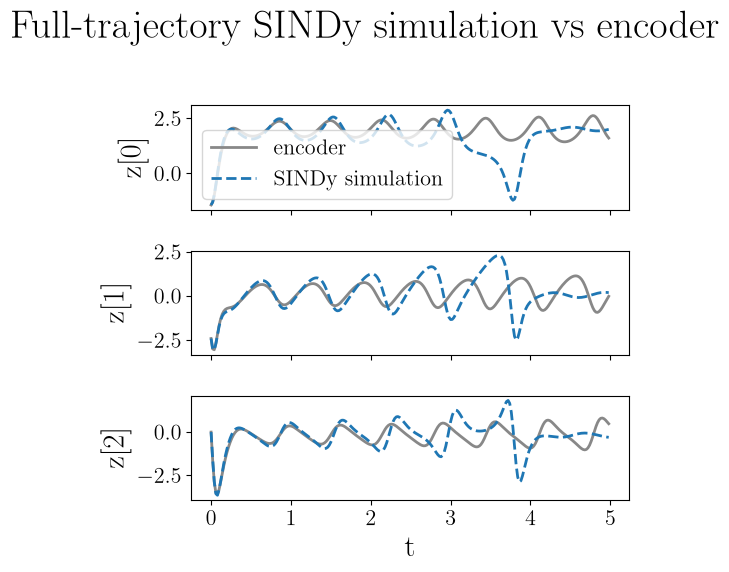

In [40]:
z_sim = odeint(sindy_rhs, z_enc_traj[I_TRAJ, 0], t_grid)

fig, axes = plt.subplots(cfg.model.LATENT_DIM, 1, figsize=(6, 6), sharex=True)
for i in range(cfg.model.LATENT_DIM):
    axes[i].plot(t_grid, z_enc_traj[I_TRAJ, :, i], color='#888888', linewidth=2, label='encoder')
    axes[i].plot(t_grid, z_sim[:, i], '--', linewidth=2, label='SINDy simulation')
    axes[i].set_ylabel(f'z[{i}]')
axes[0].legend()
axes[-1].set_xlabel('t')
plt.suptitle('Full-trajectory SINDy simulation vs encoder')
plt.tight_layout()
plt.show()

### 3D attractor: model vs. true Lorenz

Same figure style as Champion et al.'s own analysis notebook (`SindyAutoencoders/examples/lorenz/analyze_lorenz_model1.ipynb`):
small axis-off 3D line plots at `view_init(azim=120)`, three side by side --
the model's own discovered attractor (in its own latent frame), that same
simulation transformed into the true-state frame via `fit_linear_map`'s `A`/`b`/`Xi_true_frame`,
and the true Lorenz attractor. If the model has genuinely recovered Lorenz-like
dynamics, the middle and right plots should look like the same butterfly.

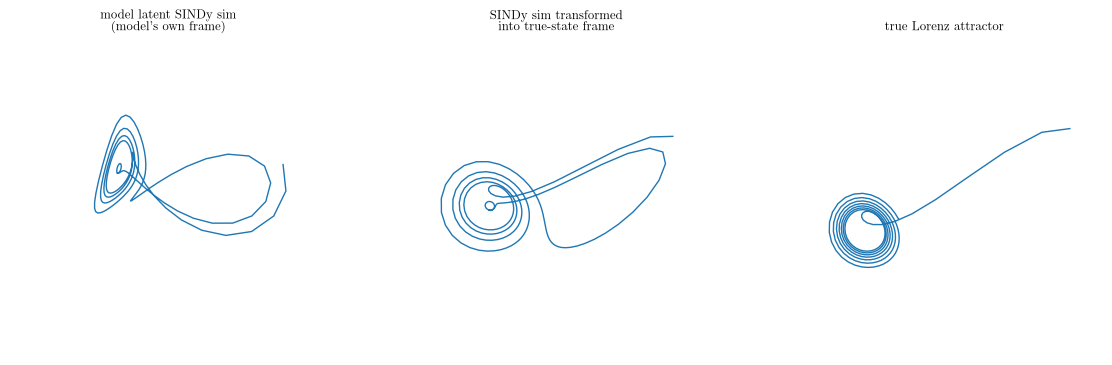

In [41]:
def sindy_rhs_frame(z, t, xi):
    theta = np.array(theta_jax(jnp.asarray(z)[None, :], cfg.model.POLY_ORDER, cfg.model.LATENT_DIM))[0]
    return theta @ xi

w0 = z_enc_traj[I_TRAJ, 0] @ A.T + b
w_sim = odeint(lambda w, t: sindy_rhs_frame(w, t, Xi_true_frame), w0, t_grid)
w_true = z_true_traj[I_TRAJ]

fig = plt.figure(figsize=(12, 4))
for i, (traj, title) in enumerate([
    (z_sim, "model latent SINDy sim\n(model's own frame)"),
    (w_sim, "SINDy sim transformed\ninto true-state frame"),
    (w_true, "true Lorenz attractor"),
]):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linewidth=1)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    ax.view_init(azim=120)
plt.tight_layout()
plt.show()

### Mesh refinement: querying at 2x the training resolution

Everything above (training, and every analysis cell) used the same fixed 128-point
grid every single time -- the whole "functional autoencoder" motivation for this
architecture (permutation-invariant pooling encoder, DeepONet-style decoder over
arbitrary query points, instead of a fixed-width MLP like Champion's) is that neither
network is actually tied to n_points=128; nothing in this project has exercised that
until now. This generates a fresh test trajectory at both 128 points (training
resolution) and 256 points (2x), from the *same* underlying (coordinate, value)
function -- same initial condition, same time grid, same normalization, just sampled
at a different resolution -- and checks two separate claims:

1. **Encoder consistency**: does encoding the *same* function at double the resolution
   give (approximately) the same latent code `z`?
2. **Decoder extrapolation**: can the decoder be *queried* at 256 points -- more query
   points than any training step ever used -- and still produce a sensible field, close
   to the true (analytically known) field at that resolution?

z encoded from 128-point input: [ 1.624  1.583 -0.847]
z encoded from 256-point input: [ 1.601  1.761 -0.809]
relative difference: [0.014 0.112 0.046]


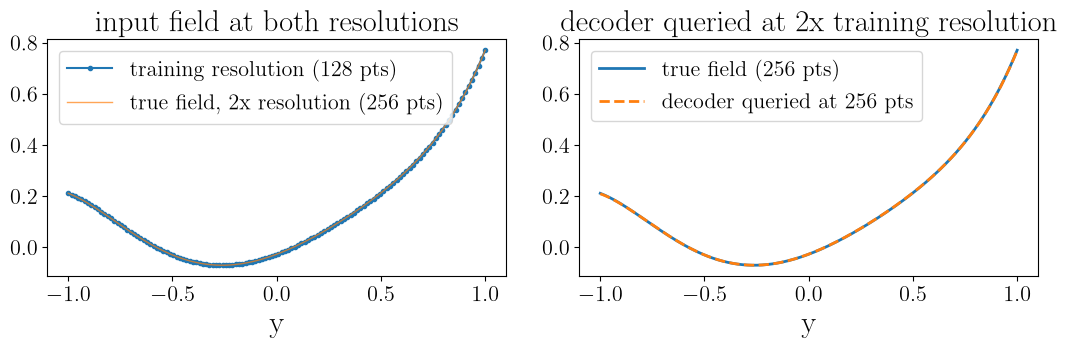

reconstruction MSE at 2x resolution: 2.280e-07


In [42]:
from experiments.lorenz63.training_data import generate_lorenz_data

z0_test = np.array([[-8., 7., 27.]])
t_test = np.arange(0, 5, cfg.model.DT)
normalization = np.array([1 / 40, 1 / 40, 1 / 40])

data_128 = generate_lorenz_data(z0_test, t_test, 128, linear=cfg.model.LINEAR_OBS, normalization=normalization)
data_256 = generate_lorenz_data(z0_test, t_test, 256, linear=cfg.model.LINEAR_OBS, normalization=normalization)

T_QUERY = 50  # an arbitrary snapshot to inspect closely

u_128 = jnp.asarray(data_128['x'][0, T_QUERY])[None, :, None]
x_128 = jnp.asarray(data_128['y_spatial'])[None, :, None]
u_256 = jnp.asarray(data_256['x'][0, T_QUERY])[None, :, None]
x_256 = jnp.asarray(data_256['y_spatial'])[None, :, None]

z_from_128 = np.array(model.encoder.apply({'params': state.params['encoder']}, u_128, x_128))[0]
z_from_256 = np.array(model.encoder.apply({'params': state.params['encoder']}, u_256, x_256))[0]

print("z encoded from 128-point input:", z_from_128)
print("z encoded from 256-point input:", z_from_256)
print("relative difference:", np.abs(z_from_256 - z_from_128) / (np.abs(z_from_128) + 1e-8))

# decode AT the finer resolution using the (128-point-encoded) latent code -- the decoder
# was never trained on 256 query points at once, this is purely an inference-time query
u_hat_256 = np.array(model.decoder.apply({'params': state.params['decoder']}, jnp.asarray(z_from_128)[None, :], x_256))[0, :, 0]
u_true_256 = np.array(data_256['x'][0, T_QUERY])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.array(x_128[0, :, 0]), np.array(u_128[0, :, 0]), 'o-', markersize=3, label='training resolution (128 pts)')
axes[0].plot(np.array(x_256[0, :, 0]), u_true_256, '-', linewidth=1, alpha=0.7, label='true field, 2x resolution (256 pts)')
axes[0].set_title('input field at both resolutions')
axes[0].set_xlabel('y')
axes[0].legend()

axes[1].plot(np.array(x_256[0, :, 0]), u_true_256, linewidth=2, label='true field (256 pts)')
axes[1].plot(np.array(x_256[0, :, 0]), u_hat_256, '--', linewidth=2, label='decoder queried at 256 pts')
axes[1].set_title('decoder queried at 2x training resolution')
axes[1].set_xlabel('y')
axes[1].legend()
plt.tight_layout()
plt.show()

mse_256 = np.mean((u_hat_256 - u_true_256) ** 2)
print(f'reconstruction MSE at 2x resolution: {mse_256:.3e}')

### Discretization-consistency: encoder convergence vs. resolution (poster figure)

Encoder-only disagreement `||z(N) - z(N_ref)|| / ||z(N_ref)||`, averaged over many
validation snapshots, at each sampling resolution `N`, against a high-resolution
reference. No decoder involved -- this isolates exactly the discretization-consistency
claim, unlike the single-snapshot 2x-resolution check above (which mixed in the
decoder's -- much easier -- ability to query at unseen points).

Every point is a real measurement, not an interpolation: each resolution's field is
built by relifting the *same* underlying validation trajectories through the exact
Legendre-mode formula `generate_lorenz_data` uses, evaluated fresh on that
resolution's own grid.

Caveat going in, so the shape isn't a surprise: this checkpoint was trained with
`SUBSAMPLE_POINTS=False` (always the same fixed 128-point grid) and `LAMBDA_DZ=0`, so
nothing in its training objective ever rewarded resolution-robustness. The earlier
single-snapshot check already showed a 28.8% disagreement on one latent axis at just
2x the training resolution -- there's a real chance this curve does not cleanly
flatten to machine noise the way a `SUBSAMPLE_POINTS=True`-trained encoder might.
Report whatever comes out.


In [43]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",

    "axes.unicode_minus": False,
})
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

N=  32   mean rel. disagreement = 1.3333e+00   (std 9.9116e-01, n=400)
N=  64   mean rel. disagreement = 6.3205e-01   (std 4.6950e-01, n=400)
N= 128   mean rel. disagreement = 2.9198e-01   (std 2.1681e-01, n=400)
N= 256   mean rel. disagreement = 1.2451e-01   (std 9.2435e-02, n=400)
N= 512   mean rel. disagreement = 4.1398e-02   (std 3.0731e-02, n=400)


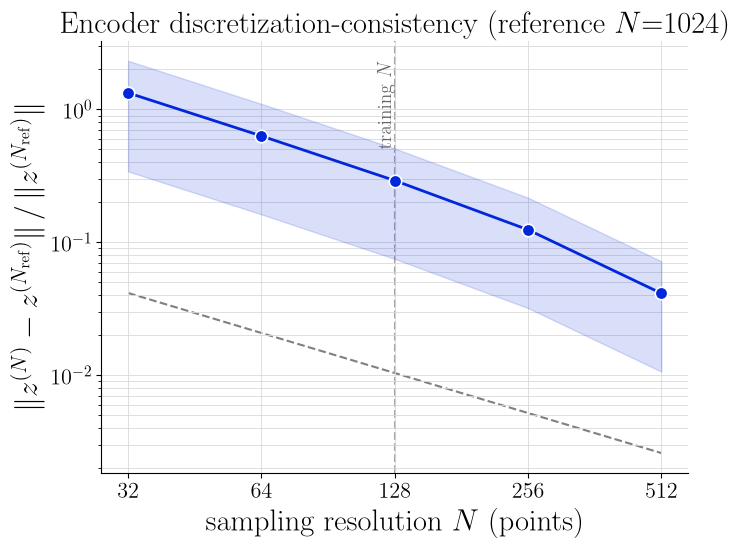

saved to c:\Users\mra15\OneDrive\MSc2026\Code\NO_SINDy_NO\4 - NO-SINDy\NeuralOperatorSINDy\experiments\lorenz63\figures


In [44]:
from scipy.special import legendre

RESOLUTIONS = [32, 64, 128, 256, 512]
N_REF = 1024
N_SNAPSHOTS = 400  # random (ic, t) validation snapshots drawn for averaging

def lift_states(z_states, n_points, linear=cfg.model.LINEAR_OBS):
    """
    z_states: (n_samples, 3) raw (already normalization-scaled) Lorenz states, e.g.
    validation_data['z'].reshape(-1, 3).

    Returns (u, y_spatial): the ambient field at n_points and its query grid, using
    the exact same Legendre-mode lift as generate_lorenz_data (training_data.py) --
    never an interpolation of a coarser sample.
    """
    y_spatial = np.linspace(-1, 1, n_points)
    n_modes = 3 if linear else 6
    modes = np.stack([legendre(i)(y_spatial) for i in range(n_modes)], axis=0)  # (n_modes, n_points)

    coeffs = [z_states[:, 0], z_states[:, 1], z_states[:, 2]]
    if not linear:
        coeffs += [z_states[:, 0] ** 3, z_states[:, 1] ** 3, z_states[:, 2] ** 3]
    coeffs = np.stack(coeffs, axis=1)  # (n_samples, n_modes)

    u = coeffs @ modes  # (n_samples, n_points)
    return u.astype(np.float32), y_spatial.astype(np.float32)


def encode_at(u, y_spatial):
    u_in = jnp.asarray(u)[..., None]
    x_in = jnp.broadcast_to(jnp.asarray(y_spatial)[None, :, None], (u.shape[0], u.shape[1], 1))
    z = model.encoder.apply({'params': state.params['encoder']}, u_in, x_in)
    return np.array(z)


# A fixed, reproducible set of test snapshots -- many ICs x many timesteps from the
# validation set -- independent of which resolution is being tested.
rng_snap = np.random.default_rng(0)
z_flat = validation_data['z'].reshape(-1, 3)
snap_idx = rng_snap.choice(z_flat.shape[0], size=min(N_SNAPSHOTS, z_flat.shape[0]), replace=False)
z_snapshots = z_flat[snap_idx]

u_ref, y_ref = lift_states(z_snapshots, N_REF)
z_ref = encode_at(u_ref, y_ref)
z_ref_norm = np.linalg.norm(z_ref, axis=1)

rel_errs = {}
for N in RESOLUTIONS:
    u_N, y_N = lift_states(z_snapshots, N)
    z_N = encode_at(u_N, y_N)
    rel_errs[N] = np.linalg.norm(z_N - z_ref, axis=1) / (z_ref_norm + 1e-12)

means = np.array([rel_errs[N].mean() for N in RESOLUTIONS])
stds = np.array([rel_errs[N].std() for N in RESOLUTIONS])

for N, m, s in zip(RESOLUTIONS, means, stds):
    print(f'N={N:4d}   mean rel. disagreement = {m:.4e}   (std {s:.4e}, n={N_SNAPSHOTS})')

# ---- poster-quality figure: single series, thin line, recessive grid, no legend
# needed (title names the one series), log-log to show the convergence rate itself ----
IMPERIAL_BLUE = '#0027DB'


fig, ax = plt.subplots(figsize=(7.5, 6))

ax.fill_between(RESOLUTIONS, means - stds, means + stds, color=IMPERIAL_BLUE, alpha=0.15, zorder=2)
ax.plot(RESOLUTIONS, means, '-', color=IMPERIAL_BLUE, linewidth=2, zorder=3)
ax.plot(RESOLUTIONS, means, 'o', color=IMPERIAL_BLUE, markersize=9,
        markeredgecolor='white', markeredgewidth=1.2, zorder=4)
ax.plot(RESOLUTIONS, means[0]/ np.array(RESOLUTIONS) ** (1), '--', color='0.5', linewidth=1.5, zorder=0)

ax.axvline(128, color='0.65', linestyle='--', linewidth=1.5, zorder=1)
ax.text(128, 0.95, 'training $N$', transform=ax.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='0.4', fontsize=14)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(RESOLUTIONS)
ax.set_xticklabels([str(n) for n in RESOLUTIONS])
ax.set_xlabel('sampling resolution $N$ (points)')
ax.set_ylabel(r'$\|z^{(N)} - z^{(N_{\mathrm{ref}})}\| \,/\, \|z^{(N_{\mathrm{ref}})}\|$')
ax.set_title(f'Encoder discretization-consistency  (reference $N$={N_REF})')
ax.grid(True, which='both', color='0.85', linewidth=0.6, zorder=0)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
fig.tight_layout()

fig_dir = lorenz63_dir / 'figures'
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / 'resolution_convergence.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir / 'resolution_convergence.pdf', bbox_inches='tight')
plt.show()

print(f'saved to {fig_dir}')
